# 🛳️ A.ing ML 스터디 타이타닉 생존자 예측 실습

Kaggle의 [타이타닉 데이터셋](https://www.kaggle.com/datasets/euclidsoft/titianic)을 활용하여 생존 여부(`survived`)를 예측하는 분류 모델을 구축합니다.

이번 실습의 목표는 데이터 전처리, 모델 학습, 성능 튜닝의 기본 파이프라인을 익히고, 공정한 기준으로 모델의 성능을 평가하는 것입니다.

---

## 🚦 실습 규칙

공정한 성능 비교를 위해 모든 팀은 다음 규칙을 반드시 준수해야 합니다. (운영진이 코드 검사 예정)

1.  **데이터 분리:**
    공정한 평가를 위해 제공된 샘플 코드를 따라 데이터를 **Train (훈련) / Validation (검증) / Test (최종 평가)** 세트로 분리합니다. (비율 수정 X)

2.  **`random_state` 고정:**
    모든 팀은 데이터 분리 시 `random_state=0`을 반드시 사용하여 동일한 세트로 실습을 진행합니다.

3.  **올바른 튜닝:**
    모델 변경, 튜닝(피처 엔지니어링, 하이퍼파라미터 조정 등)은 **Train**과 **Validation** 세트만을 사용해야 합니다.

4.  **최종 제출:**
    **Test** 세트는 모든 튜닝이 완료된 후, **마지막 결과 제출 시에만 딱 1번** 사용해야 합니다. (데이터 누수 방지 목적)

5.  **모델 사용 범위:**
    * 공정한 경쟁을 위해, **트리 기반 앙상블 모델의 사용을 금지합니다.**
        * `XGBoost`, `LightGBM`, `CatBoost`, `RandomForest` 등
    * 샘플 코드의 `LinearRegression` 외에 다음 모델들은 허용됩니다.
        * `sklearn.linear_model` (Ridge, Lasso 등), `SVR`, `KNeighborsRegressor`, 딥러닝 (PyTorch, TensorFlow) 등

6.  **1등 팀의 발표 의무:**
    * 각 라운드의 **1등 팀**은, 다음 실습 시간에 자신들의 **모델과 핵심 코드(피처 엔지니어링)를 5분간 발표하고 질의응답**을 받아야 합니다.
    * 만약 1등 팀이 발표(설명)를 거부하거나 제대로 설명하지 못할 경우, 해당 라운드의 점수는 0점이 되며 2등 팀에게 1등 점수(와 발표 의무)가 넘어갑니다.

7.  **생성형 AI 사용 가이드:**
    * AI 사용 자체는 허용합니다. 하지만 AI에게 단순히 코드를 요구하기보다, **원리를 학습하는 용도**로 사용하는 것을 **강력히 권고**합니다.
    * **AI가 생성한 코드로 1등을 했다면, 그 원리를 본인이 직접 설명할 수 있어야 합니다.**
    * (예: "RMSE가 뭐야?" (O), "zipcode는 어떻게 처리해야 할까?" (O), "XGBoost 코드 짜줘" (X))

---

## 🏆 평가 기준

* **평가 지표: F1-Score (Macro Average)**
    * F1-Score는 모델의 정밀도(Precision)와 재현율(Recall)을 모두 고려하는 균형 잡힌 지표입니다.
    * 특히 **Macro Average** 방식은 각 클래스(생존/사망)의 성능을 동일한 가중치로 평균내기 때문에, 데이터가 불균형할 때도 모델의 성능을 정확하게 평가할 수 있습니다. (값이 높을수록 성능이 좋습니다.)

* **팀 점수:**
    * 모든 조원의 **평균 Test F1-Score (Macro Avg)** 값이 해당 조의 최종 기록이 됩니다. (서로 협력하는게 큰 도움이 되겠죠?ㅎㅎ)

* **순위 및 점수 (높은 F1-Score 순):**
    * 🥇 **1등: 3점**
    * 🥈 **2등: 2점**
    * 🥉 **3등: 1점**
    * (마지막 라운드는 포인트 2배!)
---

이 샘플 코드는 **가장 기본적인 접근 방식**입니다.<br>
이 코드를 기반으로 다양한 아이디어를 적용하여 우리 동아리 최고의 모델을 만들어보세요! 🚀

In [ ]:
# 데이터 분석 및 처리 라이브러리
import pandas as pd  # 데이터프레임을 다루기 위한 필수 라이브러리 (데이터 로드, 전처리 등)
import numpy as np   # 고성능 수치 계산 및 배열 관리를 위한 라이브러리 (로그 변환, 제곱근 등)

# 데이터 시각화 라이브러리
import matplotlib.pyplot as plt  # 기본적인 그래프를 그리기 위한 라이브러리
import seaborn as sns            # Matplotlib을 기반으로 더 통계적이고 예쁜 그래프(히트맵 등)를 그리기 위한 라이브러리

# Scikit-learn 머신러닝 라이브러리
# 전처리  모듈
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
    # LabelEncoder: 범주형 데이터를 숫자로 변환
    # StandardScaler: 수치형 피처의 스케일을 표준화 (평균 0, 표준편차 1)
    # OneHotEncoder: 범주형 피처를 원-핫 인코딩으로 변환

# 데이터 분리 모듈
from sklearn.model_selection import train_test_split
    # 데이터를 훈련(train), 검증(validation), 테스트(test) 세트로 나누기 위한 함수

# 모델 모듈
from sklearn.linear_model import LogisticRegression
    # 가장 기본적인 선형 회귀 모델 -> 로지스틱 회귀는 분류를 위한 선형 회귀임

# 평가 모듈
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 데이터 로드

In [ ]:
file = "titanic.xls" # 본인의 파일 경로로 수정해주세요
data = pd.read_excel(file)

### 데이터 탐색

In [ ]:
# 데이터 크기 확인
print(data.shape)
#데이터셋 컬럼명 출력
print(data.columns)
#데이터셋 최상위 5행 출력
data.head()

(1309, 14)
Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
#데이터셋 전반적 정보 출력
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


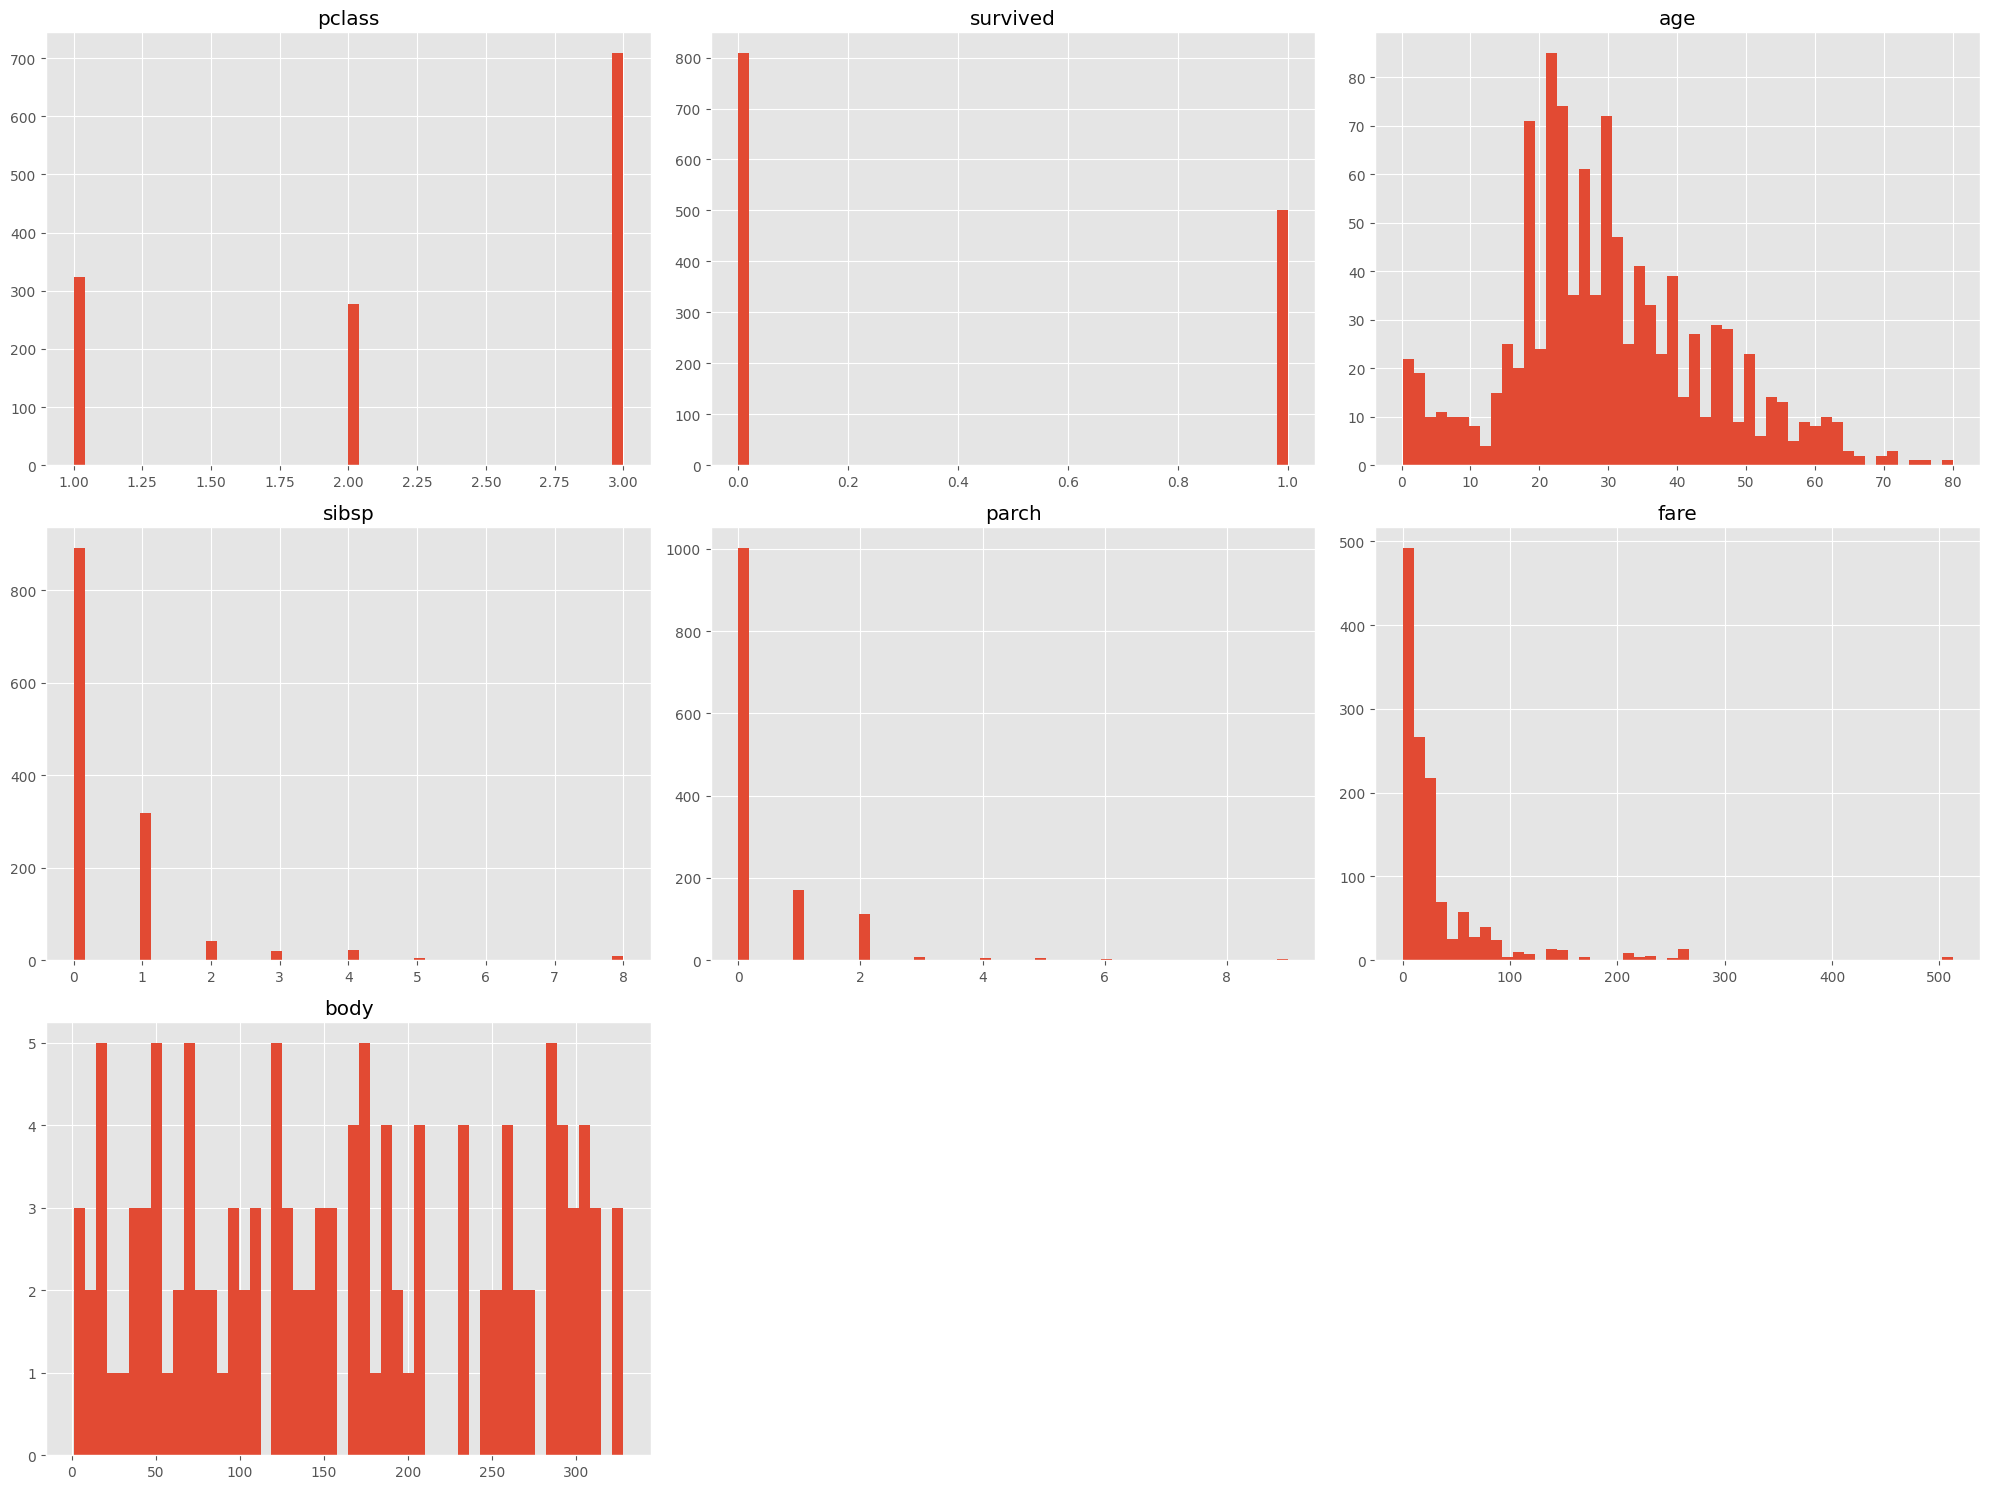

In [ ]:
plt.style.use('ggplot')
data.hist(bins=50, figsize=(20, 15))
plt.tight_layout()

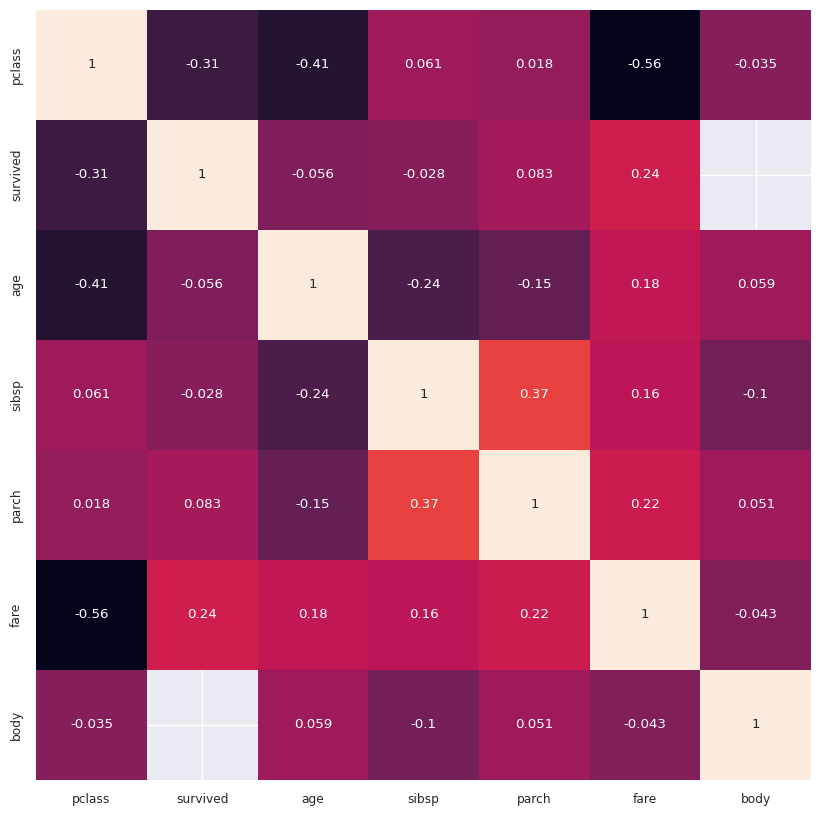

In [ ]:
house_corr=data.select_dtypes(include='number').corr()

plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(house_corr, annot=True, cbar=False)
plt.show()

### 불필요 컬럼 제거

### 피처와 타겟 분리

# GDG 코딩 행사에서 추가한 마크다운입니다!
1. name -> Title 추출 (다양한 호칭을 Mr, Mrs, Miss, Master로 통합, 이외의 호칭은 Rare로 대체)
-> age의 결측지는 해당 Title age의 평균으로 채움 (호칭별로 나이가 비슷하고 이는 생존률과 직결)
2. cabin 값이 있으면 True -> 1, 없으면 False -> 0으로 결측지 채움 -> Has Cabin열 생성 (수치형 데이터보다 범주형 데이터로 다루기 위함. 실제로 이후에 One-Hot Encoding 실행)

3. Embarked -> 최빈값으로 결측치 채우기 (.mode() attributer가 Series 객체를 반환하기 때문에 첫 번째 값이 최빈값임)
4. fare에서 중앙값으로 결측치 채우기 (평균보다 중앙값이 이상치의 영향을 덜 받기 때문임)
로그 변환으로 데이터 편향 완화
5. family_size -> Family_group으로 대체 (더 단순하게 모델이 학습할 수 있게 변환)


In [ ]:
# Feature Engineering and Initial Missing Value Handling (should be done before train/test split)

# Ensure data is freshly loaded to avoid KeyError if executed multiple times
data = pd.read_excel(file)

# 1. Drop initial unnecessary columns (errors='ignore' for robustness)
data = data.drop(['boat', 'body', 'home.dest'], axis=1, errors='ignore')

# 2. 'Name' 열에서 호칭(Title)을 추출하여 새 'Title' 열 생성
data['Title'] = data['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 3. 'Title' 값 정리 (다양한 호칭을 주요 5개 카테고리로 통합)
data['Title'] = data['Title'].replace(['Mlle', 'Ms'], 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')
other_titles = [title for title in data['Title'].unique() if title not in ['Mr', 'Mrs', 'Miss', 'Master']]
data['Title'] = data['Title'].replace(other_titles, 'Rare')

# 4. 'Title' 그룹별 'Age'의 중앙값(median)으로 'Age' 결측치 채우기
data['age'] = data.groupby('Title')['age'].transform(lambda x: x.fillna(x.median()))
if data['age'].isnull().sum() > 0:
    data['age'] = data['age'].fillna(data['age'].median())

# 5. 'Cabin' 열의 결측치 여부로 'Has_Cabin' (객실 유무) 파생변수 생성
data['Has_Cabin'] = data['cabin'].notnull().astype(int)

# 6. 'Embarked' 열의 결측치(2개)를 최빈값(mode)으로 채우기
embarked_mode = data['embarked'].mode()[0]
data['embarked'] = data['embarked'].fillna(embarked_mode)

# 7. 'Fare' 열의 결측치 처리 (로그 변환 전)
# 전체 데이터의 중앙값으로 채웁니다.
data['fare'] = data['fare'].fillna(data['fare'].median())

# 8. FamilySize 및 FamilyGroup 파생변수 생성 (sibsp와 parch 사용)
data['familysize'] = data['sibsp'] + data['parch'] + 1
data.loc[data['familysize'] == 1, 'familygroup'] = 'Alone'
data.loc[(data['familysize'] > 1) & (data['familysize'] < 5), 'familygroup'] = 'Small'
data.loc[data['familysize'] >= 5, 'familygroup'] = 'Large'

# 9. Fare 로그 변환
data['fare'] = np.log1p(data['fare'])

# 10. 원본 정보가 추출된 열('Name', 'Cabin', 'Ticket') 및 파생에 사용된 중간 특성('sibsp', 'parch', 'familysize')을 삭제합니다.
data = data.drop(['name', 'cabin', 'ticket', 'sibsp', 'parch', 'familysize'], axis=1, errors='ignore')

print("Data after feature engineering and initial missing value handling:")
print(data.info())
print(data.isnull().sum())

# X와 y 분리
X = data.drop('survived', axis=1)
y = data['survived']

X.shape, y.shape

Data after feature engineering and initial missing value handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pclass       1309 non-null   int64  
 1   survived     1309 non-null   int64  
 2   sex          1309 non-null   object 
 3   age          1309 non-null   float64
 4   fare         1309 non-null   float64
 5   embarked     1309 non-null   object 
 6   Title        1309 non-null   object 
 7   Has_Cabin    1309 non-null   int64  
 8   familygroup  1309 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 92.2+ KB
None
pclass         0
survived       0
sex            0
age            0
fare           0
embarked       0
Title          0
Has_Cabin      0
familygroup    0
dtype: int64


((1309, 8), (1309,))

### 훈련 / 테스트 데이터 분리

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((837, 8), (210, 8), (262, 8), (837,), (210,), (262,))

### 결측치 처리
결측치를 채울 기준값(중앙값, 최빈값)은 반드시 훈련 데이터에서만 계산해야 합니다. <br>
검증/테스트 데이터는 훈련 데이터의 기준값을 가져와서 채웁니다. (데이터 누수 방지)

In [ ]:
# 결측치 확인 -> train, val, test로 나눴지만 결국 data에서 분리된 것이므로 data로 확인해도 무방
data.isnull().sum()

,0
pclass,0
survived,0
sex,0
age,0
fare,0
embarked,0
Title,0
Has_Cabin,0
familygroup,0


In [ ]:
# 수치형 데이터 처리 -> 중앙값으로 채워 넣기
# age와 embarked는 이미 처리되었으므로 fare만 처리합니다.
fare_median = X_train['fare'].median()

X_train['fare'] = X_train['fare'].fillna(fare_median)
X_val['fare'] = X_val['fare'].fillna(fare_median)
X_test['fare'] = X_test['fare'].fillna(fare_median)

In [ ]:
print("---train---")
print(X_train.isnull().sum())
print("---val---")
print(X_val.isnull().sum())
print("---test---")
print(X_test.isnull().sum())

---train---
pclass         0
sex            0
age            0
fare           0
embarked       0
Title          0
Has_Cabin      0
familygroup    0
dtype: int64
---val---
pclass         0
sex            0
age            0
fare           0
embarked       0
Title          0
Has_Cabin      0
familygroup    0
dtype: int64
---test---
pclass         0
sex            0
age            0
fare           0
embarked       0
Title          0
Has_Cabin      0
familygroup    0
dtype: int64


### 전처리 (스케일링 & 인코딩)

In [ ]:
# 수치형과 범주형 데이터를 알아보기 위해 nunique() 사용 -> 컬럼에서 고유한 값의 개수를 반환
data.nunique()

,0
pclass,3
survived,2
sex,2
age,99
fare,281
embarked,3
Title,5
Has_Cabin,2
familygroup,3


In [ ]:
# 스케일링을 적용할 수치형 피처
numeric_features = [
    'age', 'fare' # 'sibsp', 'parch'는 'familygroup' 생성을 위해 사용된 후 삭제되었으므로 제외
]

# 원-핫 인코딩이 필요한 범주형 피처
categorical_features = [
    'pclass', 'sex', 'embarked', 'Title', 'Has_Cabin', 'familygroup' # 'familygroup' 추가
]

In [ ]:
# 스케일러 객체 생성
scaler = StandardScaler()

# 훈련 데이터의 연속형 피처로 평균과 분산 계산 (fit)
scaler.fit(X_train[numeric_features])

# 훈련/테스트 데이터 모두 계산된 기준으로 변환 (transform)
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(X_train.head())

      pclass     sex   age      fare embarked Title  Has_Cabin familygroup
1226       3    male  19.0  2.185579        S    Mr          0       Alone
341        2  female  12.0  3.688879        S  Miss          1       Small
1284       3    male  29.0  2.202765        S    Mr          0       Alone
145        1    male  48.0  4.353231        C    Mr          1       Small
238        1  female  43.0  5.358177        S   Mrs          1       Small


In [ ]:
# OneHotEncoder 정의
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 훈련 데이터의 범주형 피처로 범주 학습 (fit)
encoder.fit(X_train[categorical_features])

# 훈련/테스트 데이터 모두 학습된 범주 기준으로 변환 (transform)
# 변환된 NumPy 배열을 DataFrame으로 변환
train_ohe = pd.DataFrame(
    encoder.transform(X_train[categorical_features]),
    columns=encoder.get_feature_names_out(),
    index=X_train.index # 중요: 인덱스 유지
)

val_ohe = pd.DataFrame(
    encoder.transform(X_val[categorical_features]),
    columns=encoder.get_feature_names_out(),
    index=X_val.index # 인덱스 유지
)

test_ohe = pd.DataFrame(
    encoder.transform(X_test[categorical_features]),
    columns=encoder.get_feature_names_out(),
    index=X_test.index # 인덱스 유지
)

In [ ]:
# 먼저 원본 범주형 피처를 제거
X_train_processed = X_train_scaled.drop(columns=categorical_features)
X_val_processed = X_val_scaled.drop(columns=categorical_features)
X_test_processed = X_test_scaled.drop(columns=categorical_features)

# 인덱스를 기준으로 결합
X_train_processed = pd.concat([X_train_processed, train_ohe], axis=1)
X_val_processed = pd.concat([X_val_processed, val_ohe], axis=1)
X_test_processed = pd.concat([X_test_processed, test_ohe], axis=1)

### 모델 정의

In [ ]:
model = LogisticRegression()

### 모델 학습

In [ ]:
model.fit(X_train_processed, y_train)

LogisticRegression()

### 모델 검증

In [ ]:
y_pred_val = model.predict(X_val_processed)

# 2. 검증 세트의 실제 정답(y_val)과 비교하여 성능 평가
acc_val = accuracy_score(y_val, y_pred_val)
report_val = classification_report(y_val, y_pred_val)
cm_val = confusion_matrix(y_val, y_pred_val)

print("\n--- 모델 검증 (Validation) 결과 ---")
print(f'Validation Accuracy: {acc_val:.4f}')
print("\n[Classification Report]")
print(report_val)


--- 모델 검증 (Validation) 결과 ---
Validation Accuracy: 0.8238

[Classification Report]
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       123
           1       0.80      0.77      0.78        87

    accuracy                           0.82       210
   macro avg       0.82      0.82      0.82       210
weighted avg       0.82      0.82      0.82       210



### 검증 결과 시각화

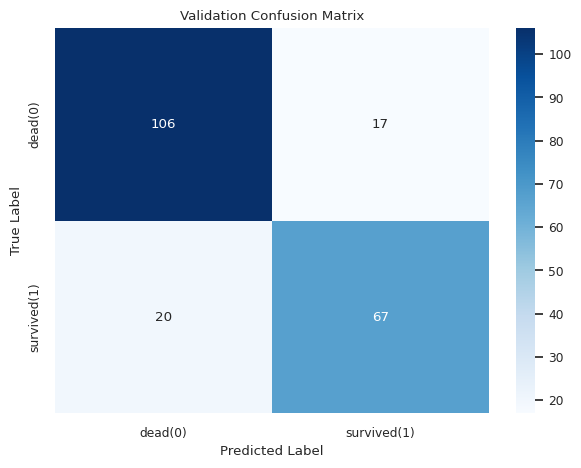

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['dead(0)', 'survived(1)'],
            yticklabels=['dead(0)', 'survived(1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.show()

## 🚨**최종 테스트**🚨
**!!최종 테스트는 꼭 마지막에 딱 한번 실행하셔야 합니다!!**

# GDG 모각코 행사에서 추가한 마크다운입니다!

accuracy: 모델이 O라고 예측한 것 중에서 실제로 O인 비율

recall: 실제로 O라고 예측한 것 중에서 모델이 O으로 예측한 비율

둘을 종합적으로 고려한 f1-score로 모델을 합리적으로 평가

In [ ]:
y_pred_test = model.predict(X_test_processed)

# 2. 테스트 세트 정답(y_test)과 비교하여 최종 성능 평가
acc_test = accuracy_score(y_test, y_pred_test)
report_test = classification_report(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print("\n--- 🏆 최종 테스트 (Test) 결과 🏆 ---")
print(f'Test Accuracy: {acc_test:.4f}')
print("\n[Classification Report]")
print(report_test)


--- 🏆 최종 테스트 (Test) 결과 🏆 ---
Test Accuracy: 0.8359

[Classification Report]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       162
           1       0.84      0.71      0.77       100

    accuracy                           0.84       262
   macro avg       0.84      0.81      0.82       262
weighted avg       0.84      0.84      0.83       262



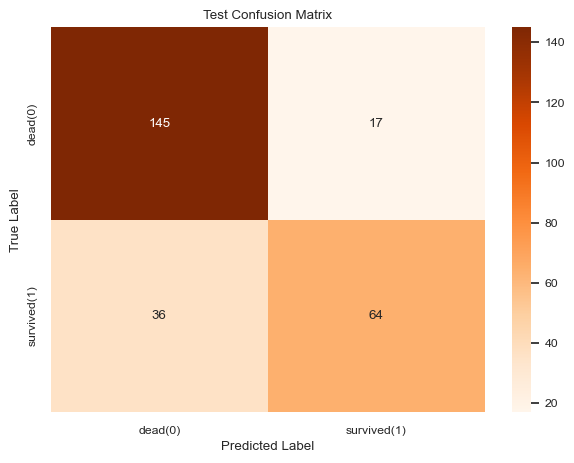

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['dead(0)', 'survived(1)'],
            yticklabels=['dead(0)', 'survived(1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()